In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn imports
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.metrics import (accuracy_score, classification_report, 
                             confusion_matrix, f1_score, precision_score, 
                             recall_score)

# XGBoost
try:
    import xgboost as xgb
    XGBOOST_AVAILABLE = True
except ImportError:
    XGBOOST_AVAILABLE = False
    print("XGBoost not installed. Skipping XGBoost model.")

print("Libraries imported successfully!")

Libraries imported successfully!


In [5]:
# Load processed datasets
train_df = pd.read_csv('../data/interim/train_processed.csv')
test_df = pd.read_csv('../data/interim/test_processed.csv')

print("Training set shape:", train_df.shape)
print("Test set shape:", test_df.shape)
print("\nTraining set columns:", train_df.columns.tolist())
print("\nFirst 5 rows of training data:")
train_df.head()

Training set shape: (29434, 2)
Test set shape: (7359, 2)

Training set columns: ['clean_comment', 'category']

First 5 rows of training data:


,clean_comment,category
0,found young modi guess one,1
1,holy shit heard whole johnny gosch story earli...,0
2,porra tava amando ler isso poderia pelo menos ...,0
3,mmw something witty add thread diwali 2016,1
4,similar chart call quality would love see low ...,0


In [6]:
# Check for missing values
print("Missing values in train:")
print(train_df.isnull().sum())
print("\nMissing values in test:")
print(test_df.isnull().sum())

# Drop rows with missing values if any
train_df = train_df.dropna()
test_df = test_df.dropna()

print("\nAfter dropping NA - Train shape:", train_df.shape)
print("After dropping NA - Test shape:", test_df.shape)

Missing values in train:
clean_comment    105
category           0
dtype: int64

Missing values in test:
clean_comment    26
category          0
dtype: int64

After dropping NA - Train shape: (29329, 2)
After dropping NA - Test shape: (7333, 2)


Training set class distribution:
category
-1     6577
 0    10083
 1    12669
Name: count, dtype: int64

Test set class distribution:
category
-1    1671
 0    2561
 1    3101
Name: count, dtype: int64


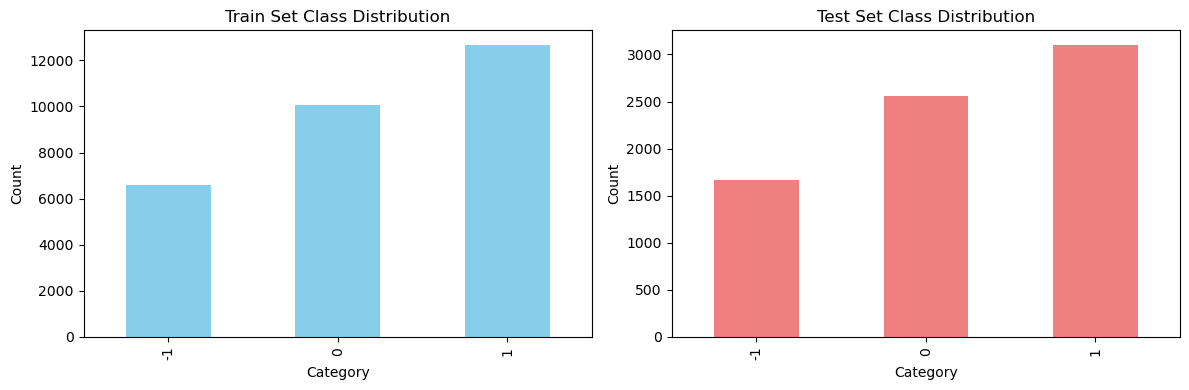

In [7]:
# Check class distribution
print("Training set class distribution:")
print(train_df['category'].value_counts().sort_index())
print("\nTest set class distribution:")
print(test_df['category'].value_counts().sort_index())

# Visualize class distribution
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
train_df['category'].value_counts().sort_index().plot(kind='bar', ax=axes[0], color='skyblue')
axes[0].set_title('Train Set Class Distribution')
axes[0].set_xlabel('Category')
axes[0].set_ylabel('Count')

test_df['category'].value_counts().sort_index().plot(kind='bar', ax=axes[1], color='lightcoral')
axes[1].set_title('Test Set Class Distribution')
axes[1].set_xlabel('Category')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

In [8]:
# Prepare features and target
X_train_text = train_df['clean_comment'].astype(str)
y_train = train_df['category']

X_test_text = test_df['clean_comment'].astype(str)
y_test = test_df['category']

# Use TF-IDF Vectorizer
print("Applying TF-IDF Vectorization...")
tfidf = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X_train_tfidf = tfidf.fit_transform(X_train_text)
X_test_tfidf = tfidf.transform(X_test_text)

print(f"TF-IDF train shape: {X_train_tfidf.shape}")
print(f"TF-IDF test shape: {X_test_tfidf.shape}")

Applying TF-IDF Vectorization...
TF-IDF train shape: (29329, 10000)
TF-IDF test shape: (7333, 10000)


In [9]:
# Also create CountVectorizer features for Naive Bayes
print("Applying Count Vectorization...")
count_vec = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    stop_words='english',
    min_df=2,
    max_df=0.95
)

X_train_count = count_vec.fit_transform(X_train_text)
X_test_count = count_vec.transform(X_test_text)

print(f"Count train shape: {X_train_count.shape}")
print(f"Count test shape: {X_test_count.shape}")

Applying Count Vectorization...
Count train shape: (29329, 10000)
Count test shape: (7333, 10000)


In [10]:
# Dictionary to store results
results = {}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, feature_type):
    """Train and evaluate a model, returning metrics."""
    print(f"\n{'='*50}")
    print(f"Training {model_name} with {feature_type}")
    print(f"{'='*50}")
    
    # Train
    model.fit(X_train, y_train)
    
    # Predict
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    f1_macro = f1_score(y_test, y_pred, average='macro')
    f1_weighted = f1_score(y_test, y_pred, average='weighted')
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    
    print(f"Accuracy: {accuracy:.4f}")
    print(f"F1 Score (Macro): {f1_macro:.4f}")
    print(f"F1 Score (Weighted): {f1_weighted:.4f}")
    print(f"Precision (Weighted): {precision:.4f}")
    print(f"Recall (Weighted): {recall:.4f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, target_names=['Negative', 'Neutral', 'Positive']))
    
    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Negative', 'Neutral', 'Positive'],
                yticklabels=['Negative', 'Neutral', 'Positive'])
    plt.title(f'Confusion Matrix - {model_name}')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.tight_layout()
    plt.show()
    
    # Store results
    result_key = f"{model_name}_{feature_type}"
    results[result_key] = {
        'Model': model_name,
        'Feature': feature_type,
        'Accuracy': accuracy,
        'F1_Macro': f1_macro,
        'F1_Weighted': f1_weighted,
        'Precision': precision,
        'Recall': recall
    }
    
    return model

### 3.1 Logistic Regression


Training LogisticRegression with TF-IDF
Accuracy: 0.8102
F1 Score (Macro): 0.7908
F1 Score (Weighted): 0.8051
Precision (Weighted): 0.8130
Recall (Weighted): 0.8102

Classification Report:
              precision    recall  f1-score   support

    Negative       0.83      0.60      0.69      1671
     Neutral       0.79      0.93      0.85      2561
    Positive       0.83      0.83      0.83      3101

    accuracy                           0.81      7333
   macro avg       0.81      0.78      0.79      7333
weighted avg       0.81      0.81      0.81      7333



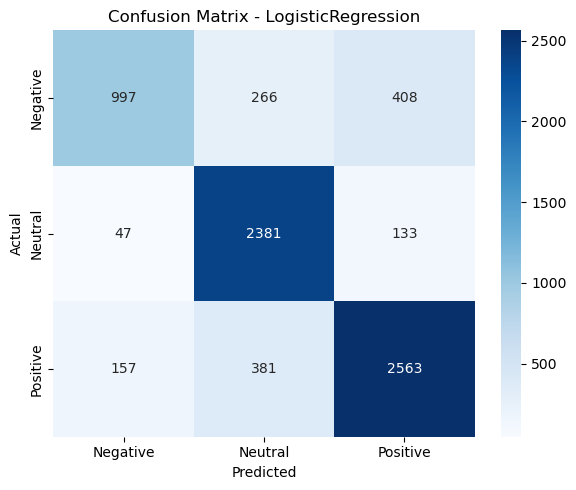

In [11]:
lr_model = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr_trained = evaluate_model(lr_model, X_train_tfidf, X_test_tfidf, 
                            y_train, y_test, "LogisticRegression", "TF-IDF")

### 3.2 Random Forest


Training RandomForest with TF-IDF
Accuracy: 0.6468
F1 Score (Macro): 0.5051
F1 Score (Weighted): 0.5742
Precision (Weighted): 0.7222
Recall (Weighted): 0.6468

Classification Report:
              precision    recall  f1-score   support

    Negative       0.98      0.03      0.06      1671
     Neutral       0.67      0.81      0.74      2561
    Positive       0.62      0.84      0.72      3101

    accuracy                           0.65      7333
   macro avg       0.76      0.56      0.51      7333
weighted avg       0.72      0.65      0.57      7333



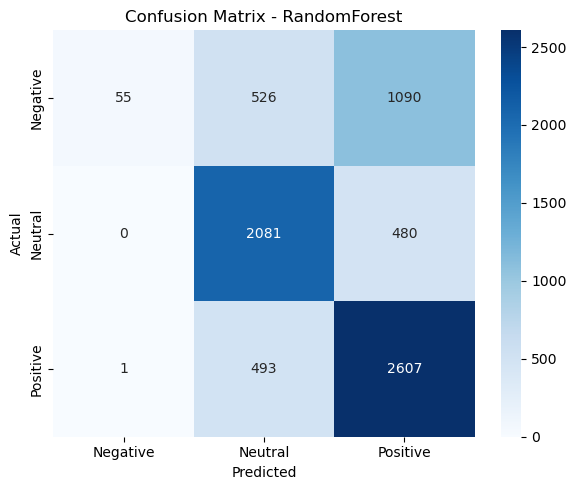

In [12]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)
rf_trained = evaluate_model(rf_model, X_train_tfidf, X_test_tfidf, 
                            y_train, y_test, "RandomForest", "TF-IDF")

### 3.3 Naive Bayes


Training NaiveBayes with CountVec
Accuracy: 0.6619
F1 Score (Macro): 0.6487
F1 Score (Weighted): 0.6581
Precision (Weighted): 0.6869
Recall (Weighted): 0.6619

Classification Report:
              precision    recall  f1-score   support

    Negative       0.61      0.60      0.60      1671
     Neutral       0.82      0.53      0.64      2561
    Positive       0.62      0.81      0.70      3101

    accuracy                           0.66      7333
   macro avg       0.68      0.64      0.65      7333
weighted avg       0.69      0.66      0.66      7333



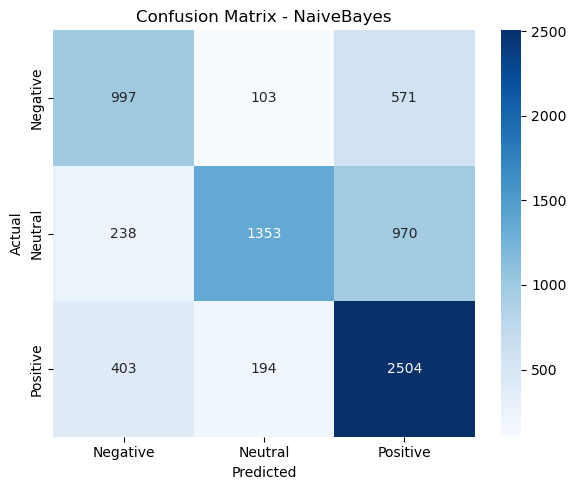

In [13]:
nb_model = MultinomialNB(alpha=0.1)
nb_trained = evaluate_model(nb_model, X_train_count, X_test_count, 
                            y_train, y_test, "NaiveBayes", "CountVec")

### 3.4 Support Vector Machine (SVM)


Training LinearSVM with TF-IDF
Accuracy: 0.8173
F1 Score (Macro): 0.8022
F1 Score (Weighted): 0.8140
Precision (Weighted): 0.8179
Recall (Weighted): 0.8173

Classification Report:
              precision    recall  f1-score   support

    Negative       0.80      0.65      0.72      1671
     Neutral       0.80      0.93      0.86      2561
    Positive       0.84      0.82      0.83      3101

    accuracy                           0.82      7333
   macro avg       0.81      0.80      0.80      7333
weighted avg       0.82      0.82      0.81      7333



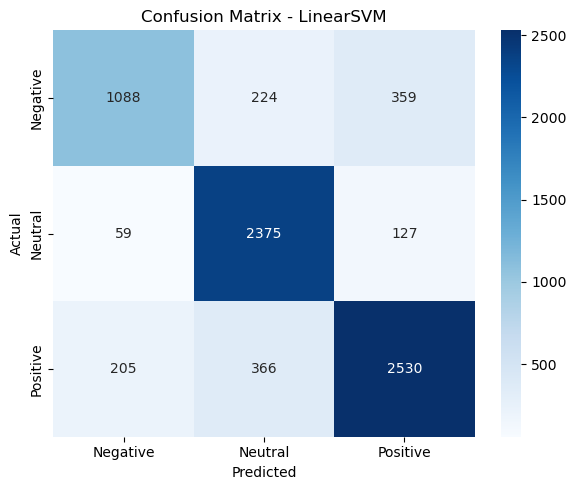

In [14]:
svm_model = LinearSVC(C=0.5, max_iter=3000, random_state=42)
svm_trained = evaluate_model(svm_model, X_train_tfidf, X_test_tfidf, 
                             y_train, y_test, "LinearSVM", "TF-IDF")

### 3.5 XGBoost

In [15]:
if XGBOOST_AVAILABLE:
    xgb_model = xgb.XGBClassifier(
        n_estimators=300,
        max_depth=10,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42,
        n_jobs=-1,
        eval_metric='mlogloss'
    )
    xgb_trained = evaluate_model(xgb_model, X_train_tfidf, X_test_tfidf, 
                                 y_train, y_test, "XGBoost", "TF-IDF")
else:
    print("Skipping XGBoost - not installed")


Training XGBoost with TF-IDF


ValueError: Invalid classes inferred from unique values of `y`.  Expected: [0 1 2], got [-1  0  1]

## 4. Model Comparison

Model Comparison (sorted by F1-Weighted Score):
                                        Model   Feature  Accuracy  F1_Macro F1_Weighted Precision    Recall
LinearSVM_TF-IDF                    LinearSVM    TF-IDF  0.817264  0.802197    0.814037  0.817865  0.817264
LogisticRegression_TF-IDF  LogisticRegression    TF-IDF  0.810173  0.790809    0.805123  0.812965  0.810173
NaiveBayes_CountVec                NaiveBayes  CountVec  0.661939  0.648671    0.658102  0.686859  0.661939
RandomForest_TF-IDF              RandomForest    TF-IDF  0.646802  0.505102    0.574236  0.722183  0.646802


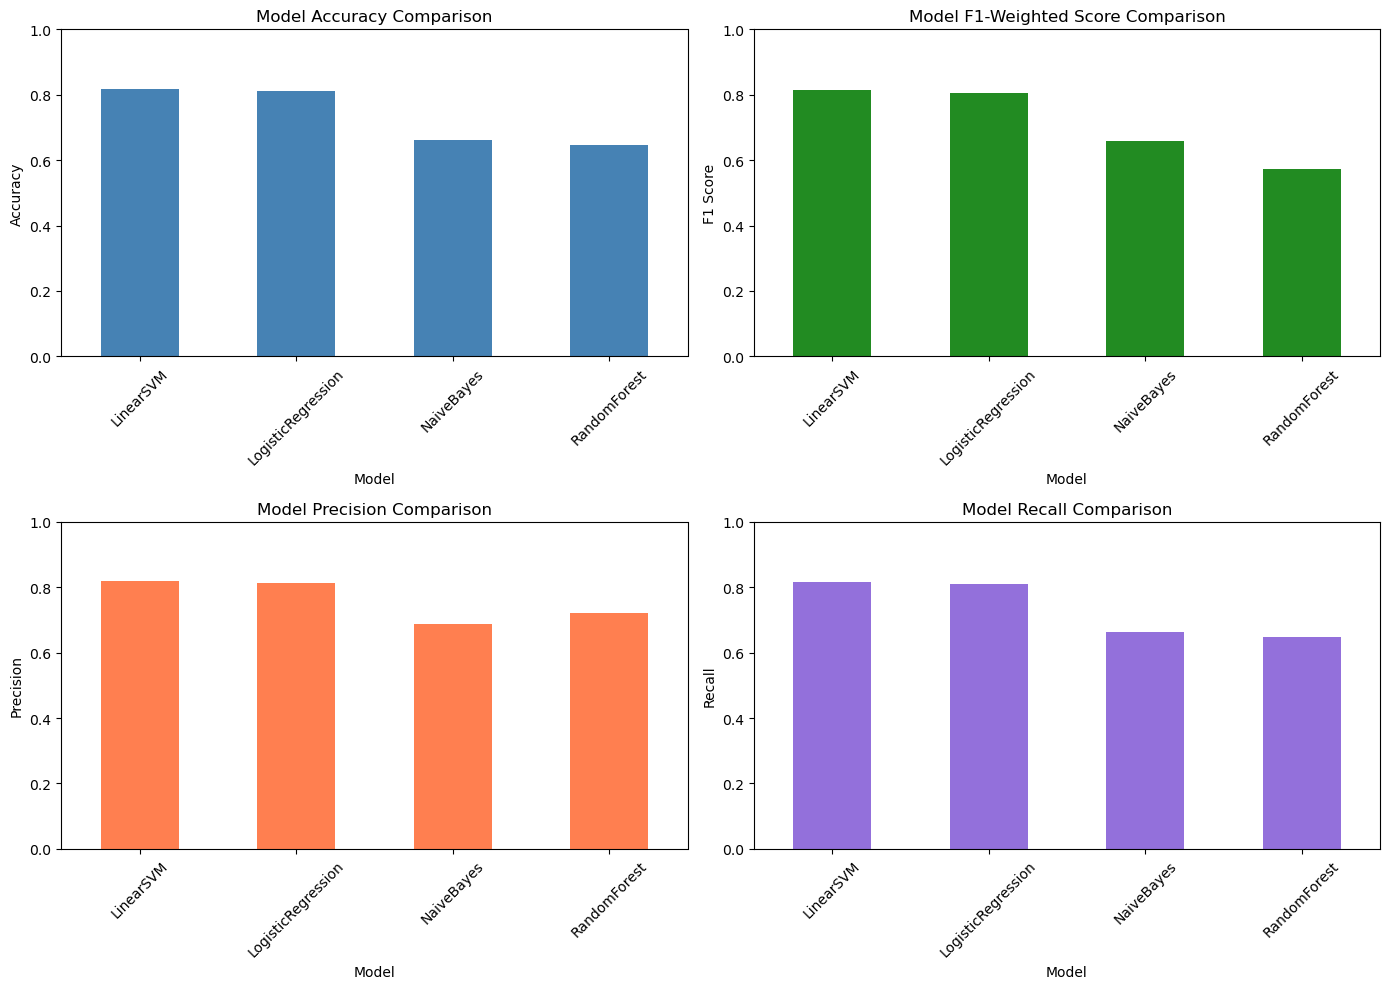

In [16]:
# Create comparison dataframe
results_df = pd.DataFrame(results).T
results_df = results_df.sort_values('F1_Weighted', ascending=False)

print("Model Comparison (sorted by F1-Weighted Score):")
print(results_df.to_string())

# Visualize comparison
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Accuracy
results_df.set_index('Model')['Accuracy'].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Model Accuracy Comparison')
axes[0,0].set_ylabel('Accuracy')
axes[0,0].set_ylim(0, 1)
axes[0,0].tick_params(axis='x', rotation=45)

# F1 Score
results_df.set_index('Model')['F1_Weighted'].plot(kind='bar', ax=axes[0,1], color='forestgreen')
axes[0,1].set_title('Model F1-Weighted Score Comparison')
axes[0,1].set_ylabel('F1 Score')
axes[0,1].set_ylim(0, 1)
axes[0,1].tick_params(axis='x', rotation=45)

# Precision
results_df.set_index('Model')['Precision'].plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Model Precision Comparison')
axes[1,0].set_ylabel('Precision')
axes[1,0].set_ylim(0, 1)
axes[1,0].tick_params(axis='x', rotation=45)

# Recall
results_df.set_index('Model')['Recall'].plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Model Recall Comparison')
axes[1,1].set_ylabel('Recall')
axes[1,1].set_ylim(0, 1)
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

## 5. Cross-Validation

In [17]:
# Perform 5-fold cross-validation on top 2 models
print("5-Fold Cross-Validation Results:")
print("="*50)

cv_models = {
    'LogisticRegression': LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1),
    'LinearSVM': LinearSVC(C=0.5, max_iter=3000, random_state=42),
    'RandomForest': RandomForestClassifier(n_estimators=200, max_depth=20, random_state=42, n_jobs=-1)
}

for name, model in cv_models.items():
    scores = cross_val_score(model, X_train_tfidf, y_train, cv=5, scoring='f1_weighted', n_jobs=-1)
    print(f"{name}: CV F1-Weighted = {scores.mean():.4f} (+/- {scores.std()*2:.4f})")

5-Fold Cross-Validation Results:
LogisticRegression: CV F1-Weighted = 0.7946 (+/- 0.0138)
LinearSVM: CV F1-Weighted = 0.8137 (+/- 0.0113)
RandomForest: CV F1-Weighted = 0.5727 (+/- 0.0127)


## 6. Save Best Model

In [18]:
import pickle
import os

# Create models directory if not exists
os.makedirs('models', exist_ok=True)

# Identify best model based on F1-Weighted score
best_model_name = results_df.iloc[0]['Model']
best_feature = results_df.iloc[0]['Feature']

print(f"Best Model: {best_model_name} with {best_feature}")
print(f"Best F1-Weighted Score: {results_df.iloc[0]['F1_Weighted']:.4f}")

# Save the best model
model_mapping = {
    'LogisticRegression': (lr_trained, tfidf),
    'RandomForest': (rf_trained, tfidf),
    'NaiveBayes': (nb_trained, count_vec),
    'LinearSVM': (svm_trained, tfidf)
}

if best_model_name in model_mapping:
    best_model, best_vectorizer = model_mapping[best_model_name]
    
    # Save model
    with open('models/best_model.pkl', 'wb') as f:
        pickle.dump(best_model, f)
    
    # Save vectorizer
    with open('models/vectorizer.pkl', 'wb') as f:
        pickle.dump(best_vectorizer, f)
    
    print("\nModel and vectorizer saved to 'models/' directory")

# Save results
results_df.to_csv('models/model_comparison_results.csv')
print("Results saved to 'models/model_comparison_results.csv'")

Best Model: LinearSVM with TF-IDF
Best F1-Weighted Score: 0.8140

Model and vectorizer saved to 'models/' directory
Results saved to 'models/model_comparison_results.csv'


## 7. Prediction on Sample Data

In [19]:
# Test prediction on sample comments
sample_comments = [
    "Modi is doing great work for the country",
    "This is a terrible decision by the government",
    "The meeting was held yesterday at the office"
]

# Transform using saved vectorizer
sample_tfidf = tfidf.transform(sample_comments)

# Predict with all models
print("Sample Predictions:")
print("="*60)

label_map = {-1: 'Negative', 0: 'Neutral', 1: 'Positive'}

for comment in sample_comments:
    print(f"\nComment: '{comment}'")
    vec = tfidf.transform([comment])
    
    if 'LogisticRegression' in model_mapping:
        pred = model_mapping['LogisticRegression'][0].predict(vec)[0]
        print(f"  LogisticRegression: {label_map[pred]}")
    
    if 'RandomForest' in model_mapping:
        pred = model_mapping['RandomForest'][0].predict(vec)[0]
        print(f"  RandomForest: {label_map[pred]}")
    
    if 'LinearSVM' in model_mapping:
        pred = model_mapping['LinearSVM'][0].predict(vec)[0]
        print(f"  LinearSVM: {label_map[pred]}")

Sample Predictions:

Comment: 'Modi is doing great work for the country'
  LogisticRegression: Positive
  RandomForest: Positive
  LinearSVM: Positive

Comment: 'This is a terrible decision by the government'
  LogisticRegression: Negative
  RandomForest: Neutral
  LinearSVM: Negative

Comment: 'The meeting was held yesterday at the office'
  LogisticRegression: Neutral
  RandomForest: Neutral
  LinearSVM: Neutral


In [20]:
print("="*60)
print("MODEL TRAINING SUMMARY")
print("="*60)
print(f"Total models trained: {len(results)}")
print(f"Best performing model: {best_model_name}")
print(f"Best Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")
print(f"Best F1-Weighted: {results_df.iloc[0]['F1_Weighted']:.4f}")
print("\nAll Model Results:")
print(results_df[['Model', 'Feature', 'Accuracy', 'F1_Weighted']].to_string(index=False))
print("="*60)

MODEL TRAINING SUMMARY
Total models trained: 4
Best performing model: LinearSVM
Best Accuracy: 0.8173
Best F1-Weighted: 0.8140

All Model Results:
             Model  Feature  Accuracy F1_Weighted
         LinearSVM   TF-IDF  0.817264    0.814037
LogisticRegression   TF-IDF  0.810173    0.805123
        NaiveBayes CountVec  0.661939    0.658102
      RandomForest   TF-IDF  0.646802    0.574236
